In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/2
    print("準備完了！このまま下のセルを実行できます。")

# 2.2 多項変数 (Multinomial Variables)
本ノートブックでは、$K$ 個の離散的な状態のいずれかをとる多項確率変数のモデル化である**多項分布 (Multinomial distribution)**、およびその共役事前分布である**ディリクレ分布 (Dirichlet distribution)** について学びます。

### 本ノートブックの構成:
1. **多項分布と最尤推定 (MLE)**: 1-of-$K$ 符号化とラグランジュ未定乗数法による最尤解の導出
2. **ディリクレ分布 (The Dirichlet Distribution)**: 多項尤度に対する共役事前分布
3. **単体 (Simplex) 上のディリクレ密度の可視化**: ハイパーパラメータ $\boldsymbol{lpha}$ による形状の変化
4. **ベイズ更新と事後予測分布**: 有効観測数としての解釈とディリクレ事後分布の進化

## 2.2.1 多項分布 (The Multinomial Distribution)

$K$ 個の相互排他的な状態のうち1つをとる変数を考えます。これを $K$ 次元の二値ベクトル $\mathbf{x} = (x_1, x_2, \dots, x_K)^T$ で表します（1-of-$K$ 表現）。
ここで $x_k \in \{0, 1\}$ かつ $\sum_{k=1}^K x_k = 1$ です。

パラメータ $\mu_k = p(x_k = 1)$ とすると、制約 $\mu_k \ge 0$ かつ $\sum_{k=1}^K \mu_k = 1$ の下で、分布は次式で与えられます。

$$ p(\mathbf{x}|\boldsymbol{\mu}) = \prod_{k=1}^K \mu_k^{x_k} $$

### 多項分布
サイズ $N$ の独立同分布データセット $\mathcal{D} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ において、各カテゴリ $k$ が観測された回数を $m_k = \sum_{n=1}^N x_{nk}$ と置くと、観測回数ベクトル $\mathbf{m} = (m_1, \dots, m_K)^T$ の確率分布は**多項分布**となります。

$$ \mathrm{Mult}(\mathbf{m}|N, \boldsymbol{\mu}) = \frac{N!}{m_1! m_2! \dots m_K!} \prod_{k=1}^K \mu_k^{m_k} $$

### 最尤推定 (MLE)
制約 $\sum_{k=1}^K \mu_k = 1$ の下でラグランジュ未定乗数法を解くと、最尤推定量は以下になります。
$$ \mu_k^{\mathrm{ML}} = \frac{m_k}{N} $$

## 2.2.2 ディリクレ分布 (The Dirichlet Distribution)

多項尤度 に対する共役事前分布として**ディリクレ分布 (Dirichlet distribution)** を導入します。

$$ \mathrm{Dir}(\boldsymbol{\mu}|\boldsymbol{lpha}) = \frac{\Gamma(lpha_0)}{\Gamma(lpha_1)\dots\Gamma(lpha_K)} \prod_{k=1}^K \mu_k^{lpha_k - 1} $$

ここで $lpha_0 = \sum_{k=1}^K lpha_k$ です。
事後分布は以下のように更新されます。
$$ p(\boldsymbol{\mu}|\mathcal{D}, \boldsymbol{lpha}) = \mathrm{Dir}(\boldsymbol{\mu}|\boldsymbol{lpha} + \mathbf{m}) $$

Plot saved to: result/fig2_4_dirichlet_distributions.png


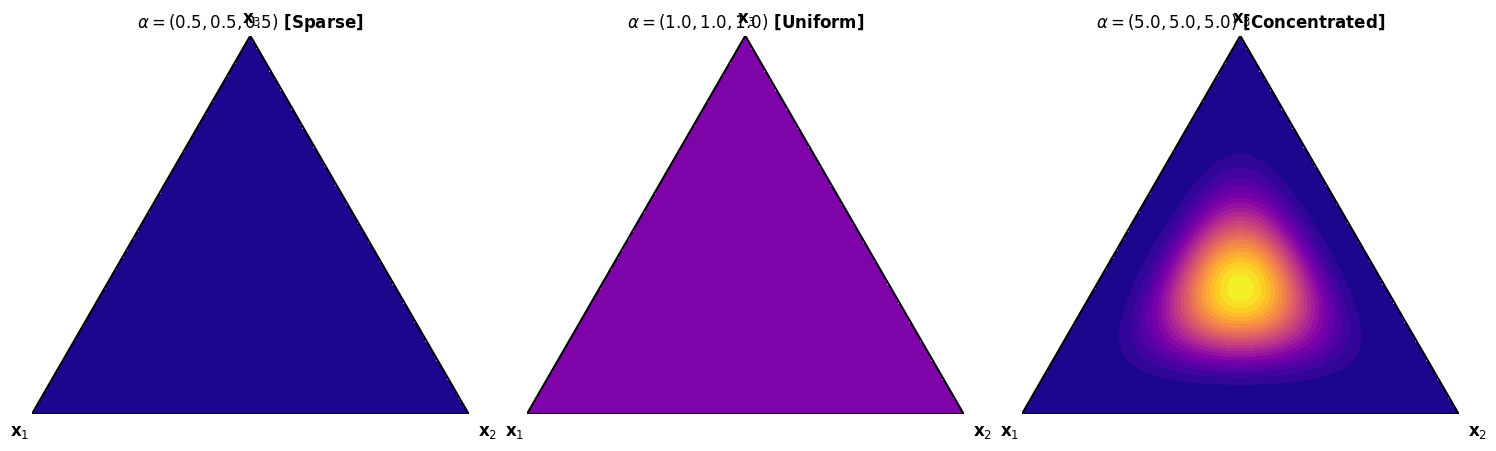

In [1]:
# 2-単体（正三角形）上でのディリクレ密度の等高線プロット (PRML Fig 2.4)
import sys, os
sys.path.append(os.path.abspath('../'))
os.makedirs("result", exist_ok=True)
from common.plot_utils import save_plot, setup_style
setup_style()

import numpy as np
import matplotlib.pyplot as plt
from prml.distributions import DirichletDistribution, plot_dirichlet_contour

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
alphas = [
    np.array([0.5, 0.5, 0.5]),  # スパース（頂点に集中）
    np.array([1.0, 1.0, 1.0]),  # 一様分布
    np.array([5.0, 5.0, 5.0]),  # 中心に集中する対称分布
]
titles = [
    r'$\alpha = (0.5, 0.5, 0.5)$ [Sparse]',
    r'$\alpha = (1.0, 1.0, 1.0)$ [Uniform]',
    r'$\alpha = (5.0, 5.0, 5.0)$ [Concentrated]'
]

for ax, alpha, title in zip(axes, alphas, titles):
    plot_dirichlet_contour(alpha, ax=ax, n_grid=200, levels=25, cmap='plasma')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
save_plot(fig, "result", "fig2_4_dirichlet_distributions.png")
plt.show()

Plot saved to: result/fig2_dirichlet_posterior_update.png


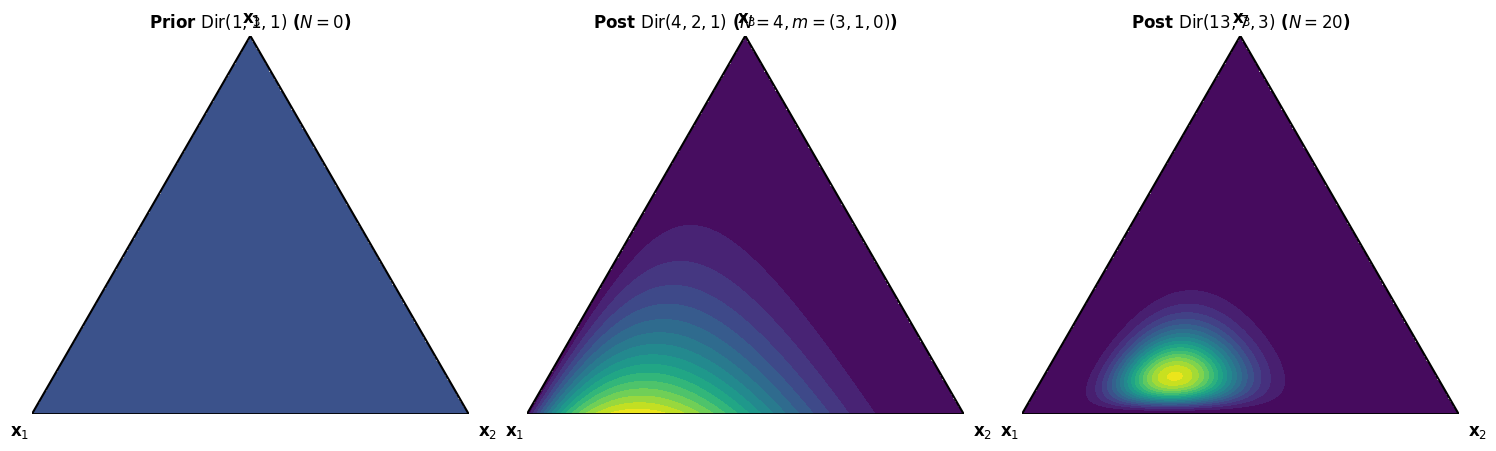

In [2]:
# 多項データの逐次観測に伴うディリクレ事後分布の更新過程
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 初期事前分布 (一様)
alpha_prior = np.array([1.0, 1.0, 1.0])
plot_dirichlet_contour(alpha_prior, ax=axes[0], levels=20, cmap='viridis')
axes[0].set_title(r'Prior $\mathrm{Dir}(1, 1, 1)$ ($N=0$)', fontsize=12, fontweight='bold')

# 観測データ 1: m = (3, 1, 0)
m1 = np.array([3, 1, 0])
post1 = alpha_prior + m1
plot_dirichlet_contour(post1, ax=axes[1], levels=20, cmap='viridis')
axes[1].set_title(r'Post $\mathrm{Dir}(4, 2, 1)$ ($N=4, m=(3,1,0)$)', fontsize=12, fontweight='bold')

# 観測データ 2: m = (12, 6, 2)
m2 = np.array([12, 6, 2])
post2 = alpha_prior + m2
plot_dirichlet_contour(post2, ax=axes[2], levels=20, cmap='viridis')
axes[2].set_title(r'Post $\mathrm{Dir}(13, 7, 3)$ ($N=20$)', fontsize=12, fontweight='bold')

plt.tight_layout()
save_plot(fig, "result", "fig2_dirichlet_posterior_update.png")
plt.show()

Plot saved to: result/fig2_multinomial_convergence.png


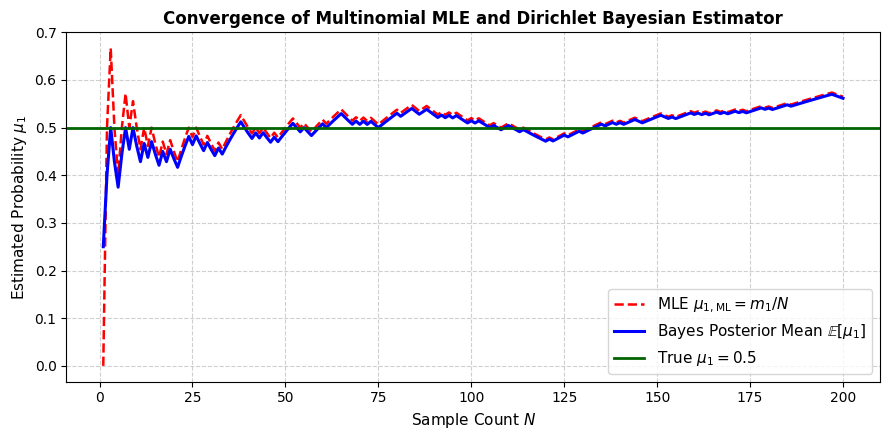

In [3]:
# 多項MLE vs ディリクレベイズ事後期待値のサンプルサイズに対する収束
np.random.seed(42)
true_mu = np.array([0.5, 0.3, 0.2])
N_total = 200
samples = np.random.multinomial(1, true_mu, size=N_total)
counts_cum = np.cumsum(samples, axis=0)
N_range = np.arange(1, N_total + 1)

mle_p0 = counts_cum[:, 0] / N_range
bayes_p0 = (1.0 + counts_cum[:, 0]) / (3.0 + N_range)

fig = plt.figure(figsize=(9, 4.5))
plt.plot(N_range, mle_p0, 'r--', lw=1.8, label=r'MLE $\mu_{1,\mathrm{ML}} = m_1 / N$')
plt.plot(N_range, bayes_p0, 'b-', lw=2.2, label=r'Bayes Posterior Mean $\mathbb{E}[\mu_1]$')
plt.axhline(true_mu[0], color='darkgreen', linestyle='-', lw=2, label=f'True $\mu_1 = {true_mu[0]}$')
plt.title('Convergence of Multinomial MLE and Dirichlet Bayesian Estimator', fontsize=12, fontweight='bold')
plt.xlabel('Sample Count $N$', fontsize=11)
plt.ylabel('Estimated Probability $\mu_1$', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
save_plot(fig, "result", "fig2_multinomial_convergence.png")
plt.show()

## まとめ
1. 多項分布の最尤推定量 $\mu_k^{\mathrm{ML}} = m_k / N$ は、観測されないカテゴリに対してゼロ確率を割り当てるゼロ頻度問題を持つ。
2. ディリクレ分布は多項分布に対する自然な共役事前分布であり、事後分布の更新はパラメータの加算 $\boldsymbol{lpha} + \mathbf{m}$ のみで実行できる。
3. ディリクレハイパーパラメータ $lpha_k$ はカテゴリ $k$ の事前有効観測数として機能し、平滑化（スムージング）をもたらす。